# NRVS drift analysis

This notebook reproduces the processing path in `drift_analysis.ipynb` in a concise, documented form. It reads every `Cell*.dat` scan and its matching `.inf` timestamp, aligns spectra to the elastic peak, rejects incomplete scans, resamples each retained scan to a shared energy grid, and obtains one spectrum at the median time of each scan.

The numerical algorithm is intentionally unchanged from the original notebook. The additional figures are quality-control views only: they make the time evolution and every processing stage directly inspectable.

**Input convention.** `x = column 1`, `y = column 8 / (column 7 × column 5)`, and the point dwell time is column 4. The `.inf` `Starting Time` values are interpreted as JST and converted to UTC, as in the original export workflow.


In [1]:
from datetime import datetime, timedelta, timezone
from pathlib import Path
import re

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# Keep paths relative to this notebook's directory.
DATA_DIR = Path("data")
FILE_PATTERN = "Cell*.dat"
TIMEZONE_ACQUISITION = timezone(timedelta(hours=9))  # JST, as used in the original notebook.
TIMEZONE_OUTPUT = timezone.utc

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Parsing helpers

The parsing and validity criteria below are the same as the original notebook. Data rows with at least nine numeric fields are retained; rows with a zero denominator or non-finite values are removed.


In [2]:
NUMBER_PATTERN = re.compile(r"[-+]?\d*\.?\d+(?:[Ee][-+]?\d+)?")
START_TIME_PATTERN = re.compile(
    r"Starting\s+Time\s+(\d{4}/\d{1,2}/\d{1,2})\s+(\d{1,2}:\d{1,2}:\d{1,2})"
)


def parse_start_time(inf_path: Path) -> datetime | None:
    """Read the naive acquisition start time from an accompanying .inf file."""
    if not inf_path.exists():
        return None
    with inf_path.open("r", encoding="utf-8", errors="ignore") as handle:
        for line in handle:
            match = START_TIME_PATTERN.search(line)
            if match is None:
                continue
            try:
                year, month, day = (int(value) for value in match.group(1).split("/"))
                hour, minute, second = (int(value) for value in match.group(2).split(":"))
                return datetime(year, month, day, hour, minute, second)
            except ValueError:
                continue
    return None


def parse_numeric_rows(dat_path: Path) -> np.ndarray:
    """Read numeric rows while tolerating irregular whitespace in beamline files."""
    rows = []
    with dat_path.open("r", encoding="utf-8", errors="ignore") as handle:
        next(handle, None)  # Header line, matching the original workflow.
        for line in handle:
            values = [float(match.group(0)) for match in NUMBER_PATTERN.finditer(line)]
            if len(values) >= 9:
                rows.append(values)
    if not rows:
        return np.empty((0, 0), dtype=float)

    # Preserve only the modal row width used by the original parser.
    max_columns = max(len(row) for row in rows)
    return np.asarray([row for row in rows if len(row) == max_columns], dtype=float)


def gaussian(x, amplitude, center, sigma, offset):
    """Local model for the elastic peak used to place it at x = 0."""
    return amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2) + offset


def as_mpl_dates(times):
    """Convert timezone-aware datetimes to Matplotlib's numerical date axis."""
    return mdates.date2num([time.replace(tzinfo=None) for time in times])


def datetime_to_ns(timestamps: pd.Series) -> np.ndarray:
    """Return UTC pandas timestamps as integer nanoseconds across pandas versions."""
    raw = timestamps.astype("int64").to_numpy(dtype=np.int64)
    # pandas 3 may store datetimes in microseconds; the original notebook's
    # `astype('int64')` workflow assumed nanoseconds. Normalize explicitly.
    unit = getattr(timestamps.dtype, "unit", "ns")
    scale_to_ns = {"s": 1_000_000_000, "ms": 1_000_000, "us": 1_000, "ns": 1}
    return raw * scale_to_ns[unit]


def waterfall_views(records, x_key, y_key, time_key, title, point_size=1.2):
    """Show a 3D side view and orthographic top view of a spectrum timeline."""
    fig = plt.figure(figsize=(15, 6.4), constrained_layout=True)
    side = fig.add_subplot(1, 2, 1, projection="3d")
    top = fig.add_subplot(1, 2, 2, projection="3d")

    all_y = np.concatenate([np.asarray(record[y_key], dtype=float) for record in records])
    colour_norm = plt.Normalize(np.nanpercentile(all_y, 1), np.nanpercentile(all_y, 99))
    mapper = plt.cm.ScalarMappable(norm=colour_norm, cmap="plasma")

    for axis in (side, top):
        for record in records:
            x = np.asarray(record[x_key], dtype=float)
            y = np.asarray(record[y_key], dtype=float)
            t_num = as_mpl_dates(record[time_key])
            axis.scatter(x, t_num, y, c=y, cmap="plasma", norm=colour_norm,
                         s=point_size, alpha=0.72, linewidths=0)
        axis.set_xlabel("Shifted X" if "shifted" in x_key or x_key == "x" else "X")
        axis.set_ylabel("UTC time")
        axis.set_zlabel("Y = col8 / (col7 × col5)")
        axis.yaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
        axis.set_proj_type("ortho")

    side.view_init(elev=20, azim=-64)
    side.set_title("Side view")
    top.view_init(elev=90, azim=-90)
    top.set_title("Top view: alignment/drift check")
    fig.suptitle(title, y=1.02, fontsize=13)
    fig.colorbar(mapper, ax=[side, top], shrink=0.72, pad=0.04, label="Y value")
    plt.show()

## 2. Load scans and construct point timestamps

Every valid point is assigned an absolute acquisition time by cumulatively adding its dwell time to the scan start time. This first waterfall is deliberately unaligned and includes all valid scans, so it is the baseline for the subsequent corrections.


Files discovered: 246
Valid scans loaded: 246
Skipped during parsing: 0


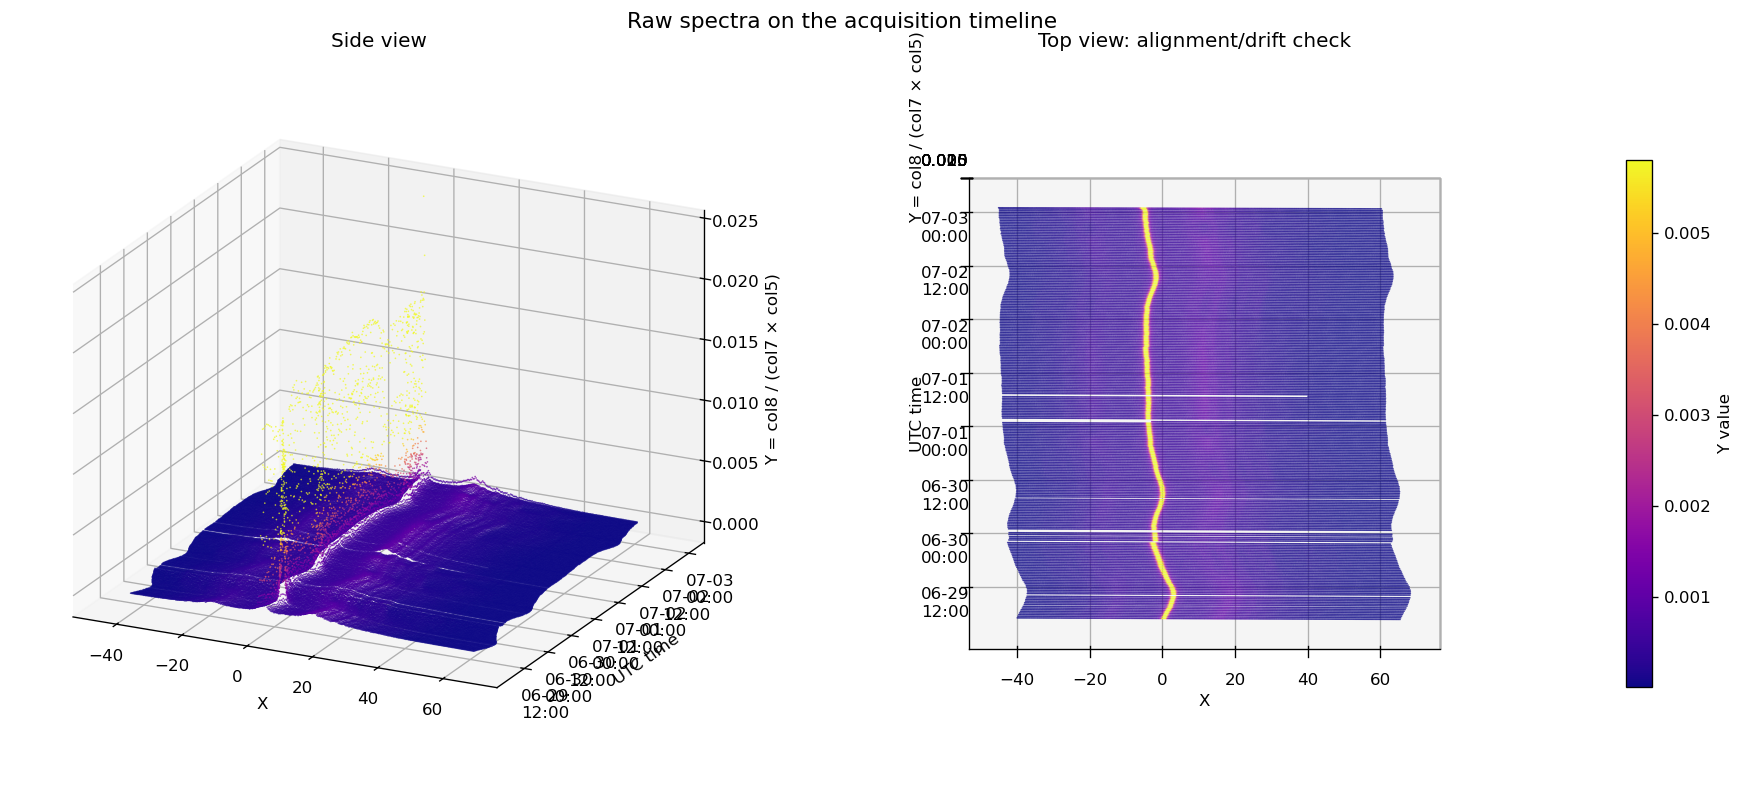

In [3]:
dat_files = sorted(DATA_DIR.glob(FILE_PATTERN))
if not dat_files:
    raise FileNotFoundError(f"No files matched {DATA_DIR / FILE_PATTERN}")

raw_records = []
skipped_files = []

for file_index, dat_path in enumerate(dat_files):
    start_time = parse_start_time(dat_path.with_suffix(".inf"))
    if start_time is None:
        skipped_files.append((dat_path.name, "missing or invalid Starting Time"))
        continue

    array = parse_numeric_rows(dat_path)
    if array.size == 0:
        skipped_files.append((dat_path.name, "no numeric rows"))
        continue

    x = array[:, 1]
    dwell_seconds = array[:, 4]
    denominator = array[:, 7] * array[:, 5]
    numerator = array[:, 8]
    valid = (
        np.isfinite(x) & np.isfinite(numerator) & np.isfinite(denominator)
        & np.isfinite(dwell_seconds) & (denominator != 0)
    )
    x, dwell_seconds = x[valid], dwell_seconds[valid]
    y = numerator[valid] / denominator[valid]
    if len(x) < 8:
        skipped_files.append((dat_path.name, "fewer than eight valid points"))
        continue

    # The original .inf clock is JST. Convert to UTC before constructing point times.
    start_utc = start_time.replace(tzinfo=TIMEZONE_ACQUISITION).astimezone(TIMEZONE_OUTPUT)
    elapsed_seconds = np.cumsum(dwell_seconds)
    point_times_utc = [start_utc + timedelta(seconds=float(value)) for value in elapsed_seconds]
    raw_records.append({
        "file_index": file_index,
        "name": dat_path.name,
        "x_raw": x,
        "y": y,
        "dwell_seconds": dwell_seconds,
        "time_utc": point_times_utc,
        "n_points": len(x),
    })

if not raw_records:
    raise RuntimeError("No valid Cell*.dat files could be processed")

print(f"Files discovered: {len(dat_files)}")
print(f"Valid scans loaded: {len(raw_records)}")
print(f"Skipped during parsing: {len(skipped_files)}")
if skipped_files:
    print("First skipped files:")
    for name, reason in skipped_files[:10]:
        print(f"  - {name}: {reason}")

waterfall_views(raw_records, "x_raw", "y", "time_utc", "Raw spectra on the acquisition timeline", point_size=1.0)

## 3. Identify incomplete scans and align the elastic peak

Exactly as in the source notebook, a bad scan is any otherwise valid scan whose point count is lower than the largest scan point count. Only maximum-length scans are retained. For each retained scan, a Gaussian is fitted near `x ≈ 0`; the fitted center is subtracted from its X axis. The fitted width from one successful scan initializes the next fit, preserving the original fit sequence.


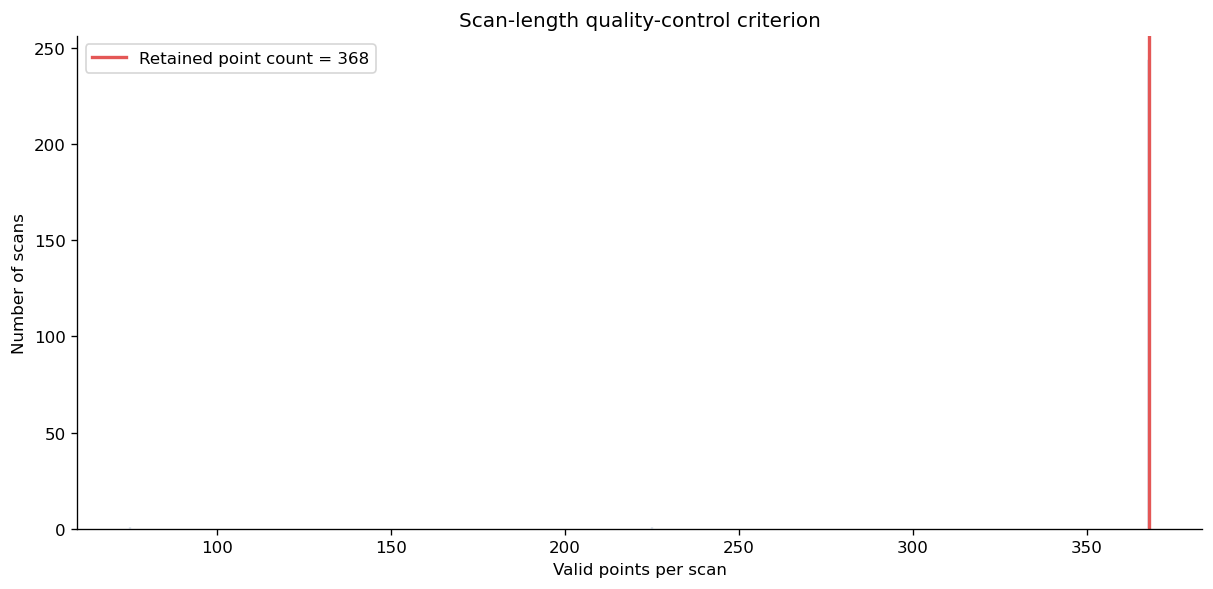

Maximum valid points in a scan: 368
Retained scans: 244 / 246
Rejected incomplete scans: 2
Rejected scans:
  - Cell3_117.dat (225 points)
  - Cell4_015.dat (75 points)
Gaussian fits completed: 244 / 244


,scan,elastic_center,sigma,status
0,Cell3_001.dat,0.459677,0.361110,fit
1,Cell3_002.dat,0.671757,0.364308,fit
2,Cell3_003.dat,0.915915,0.368919,fit
3,Cell3_004.dat,1.149908,0.371116,fit
4,Cell3_005.dat,1.384775,0.387090,fit


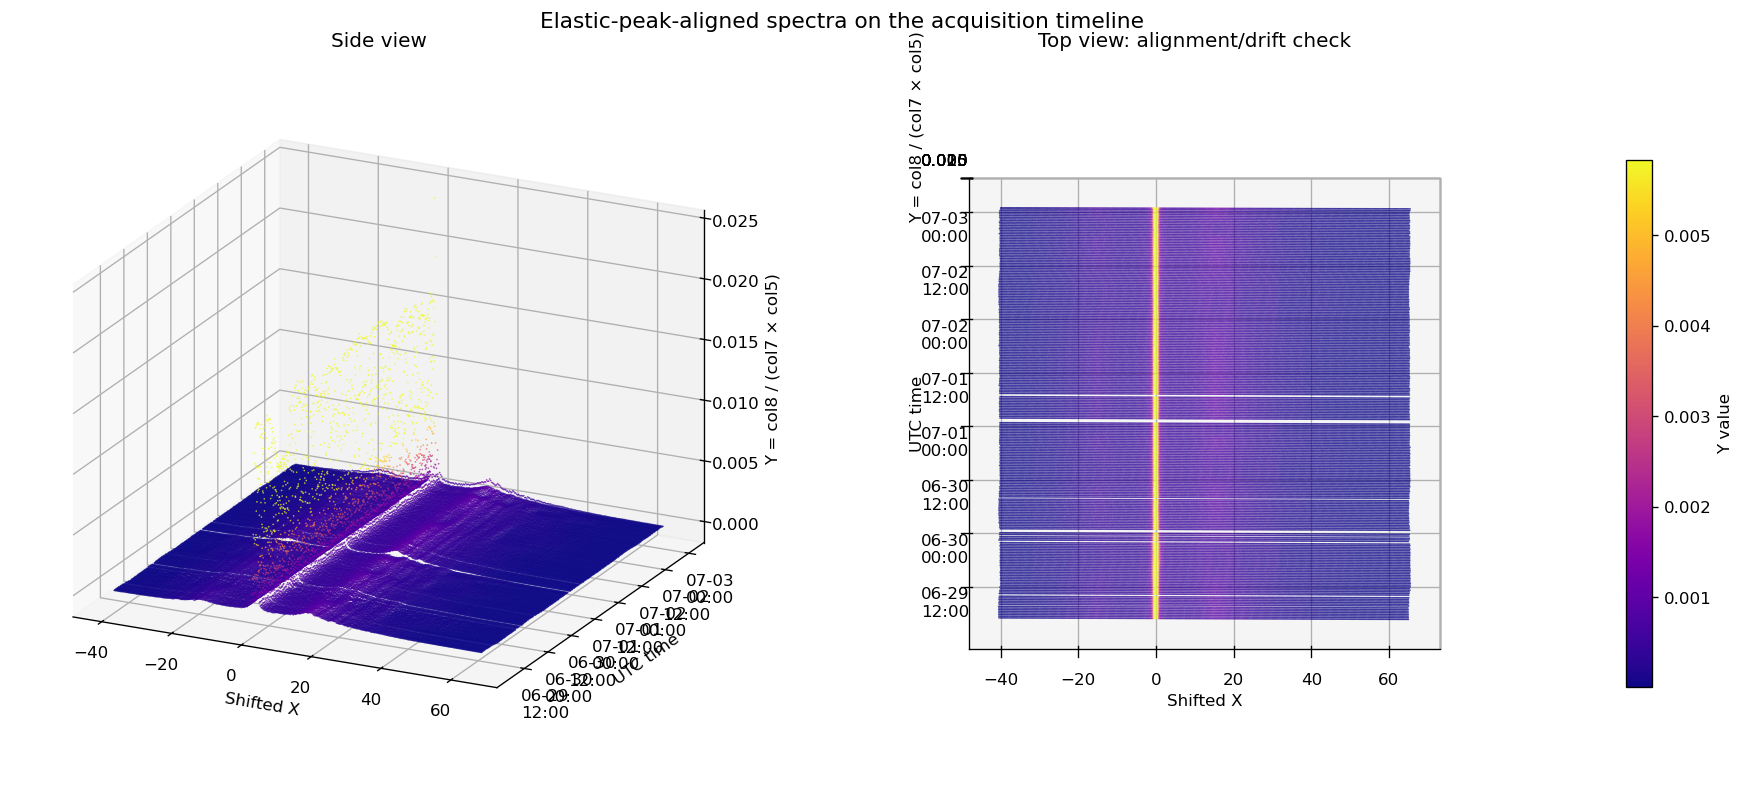

In [4]:
point_counts = np.array([record["n_points"] for record in raw_records])
max_points = int(point_counts.max())
kept_records = [record.copy() for record in raw_records if record["n_points"] == max_points]
bad_scan_records = [record for record in raw_records if record["n_points"] < max_points]

fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
ax.hist(point_counts, bins=np.arange(point_counts.min() - 0.5, point_counts.max() + 1.5),
        color="#4C78A8", edgecolor="white")
ax.axvline(max_points, color="#E45756", linewidth=2, label=f"Retained point count = {max_points}")
ax.set(xlabel="Valid points per scan", ylabel="Number of scans", title="Scan-length quality-control criterion")
ax.legend()
plt.show()

print(f"Maximum valid points in a scan: {max_points}")
print(f"Retained scans: {len(kept_records)} / {len(raw_records)}")
print(f"Rejected incomplete scans: {len(bad_scan_records)}")
if bad_scan_records:
    print("Rejected scans:")
    for record in bad_scan_records:
        print(f"  - {record['name']} ({record['n_points']} points)")

previous_sigma = 2.0
fit_rows = []
for record in kept_records:
    x, y = record["x_raw"], record["y"]
    near_zero = np.abs(x) <= 20.0
    if np.count_nonzero(near_zero) < 8:
        near_zero = np.ones_like(x, dtype=bool)

    x_near_zero, y_near_zero = x[near_zero], y[near_zero]
    coarse_center = float(x_near_zero[np.argmax(y_near_zero)])
    half_width = max(6.0, 4.0 * previous_sigma)
    fit_mask = np.abs(x - coarse_center) <= half_width
    if np.count_nonzero(fit_mask) < 8:
        fit_mask = near_zero

    x_fit, y_fit = x[fit_mask], y[fit_mask]
    initial_guess = [
        float(np.max(y_fit) - np.median(y_fit)),
        coarse_center,
        float(max(previous_sigma, 0.2)),
        float(np.median(y_fit)),
    ]
    try:
        parameters, _ = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, maxfev=20_000)
        fitted_center = float(parameters[1])
        fitted_sigma = abs(float(parameters[2]))
        if np.isfinite(fitted_sigma) and fitted_sigma > 0:
            previous_sigma = fitted_sigma
        fit_status = "fit"
    except Exception:
        # Same fallback as the original: retain the coarse peak location.
        fitted_center = coarse_center
        fitted_sigma = previous_sigma
        fit_status = "coarse fallback"

    record["x_shifted"] = x - fitted_center
    record["elastic_center"] = fitted_center
    record["elastic_sigma"] = fitted_sigma
    record["fit_status"] = fit_status
    fit_rows.append((record["name"], fitted_center, fitted_sigma, fit_status))

fit_table = pd.DataFrame(fit_rows, columns=["scan", "elastic_center", "sigma", "status"])
print(f"Gaussian fits completed: {(fit_table['status'] == 'fit').sum()} / {len(fit_table)}")
display(fit_table.head())

waterfall_views(kept_records, "x_shifted", "y", "time_utc",
                "Elastic-peak-aligned spectra on the acquisition timeline", point_size=1.0)

## 4. Interpolate every retained scan onto a common X grid

The shared range and interpolation follow the original timestamp-aware export sequence exactly:

- `x_max_common` is the minimum first X value across scans;
- `x_min_common` is the maximum last X value across scans;
- the grid contains the largest retained point count;
- both Y values and their UTC timestamps are linearly interpolated after sorting by X.

The side/top waterfall pairs compare the aligned point clouds to the resampled profiles. The accompanying timestamp panel checks that the interpolation has produced a common X grid while retaining a smoothly varying acquisition timeline.


Common X grid: [-39.868286, 64.881445] with 368 points
x_max boundary: Cell3_008.dat → 64.881445
x_min boundary: Cell3_022.dat → -39.868286


C:\Users\rual\AppData\Local\Temp\ipykernel_23788\1029561167.py:56: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  "time_utc_interp": list(frame["time_utc_interp"].dt.to_pydatetime())}


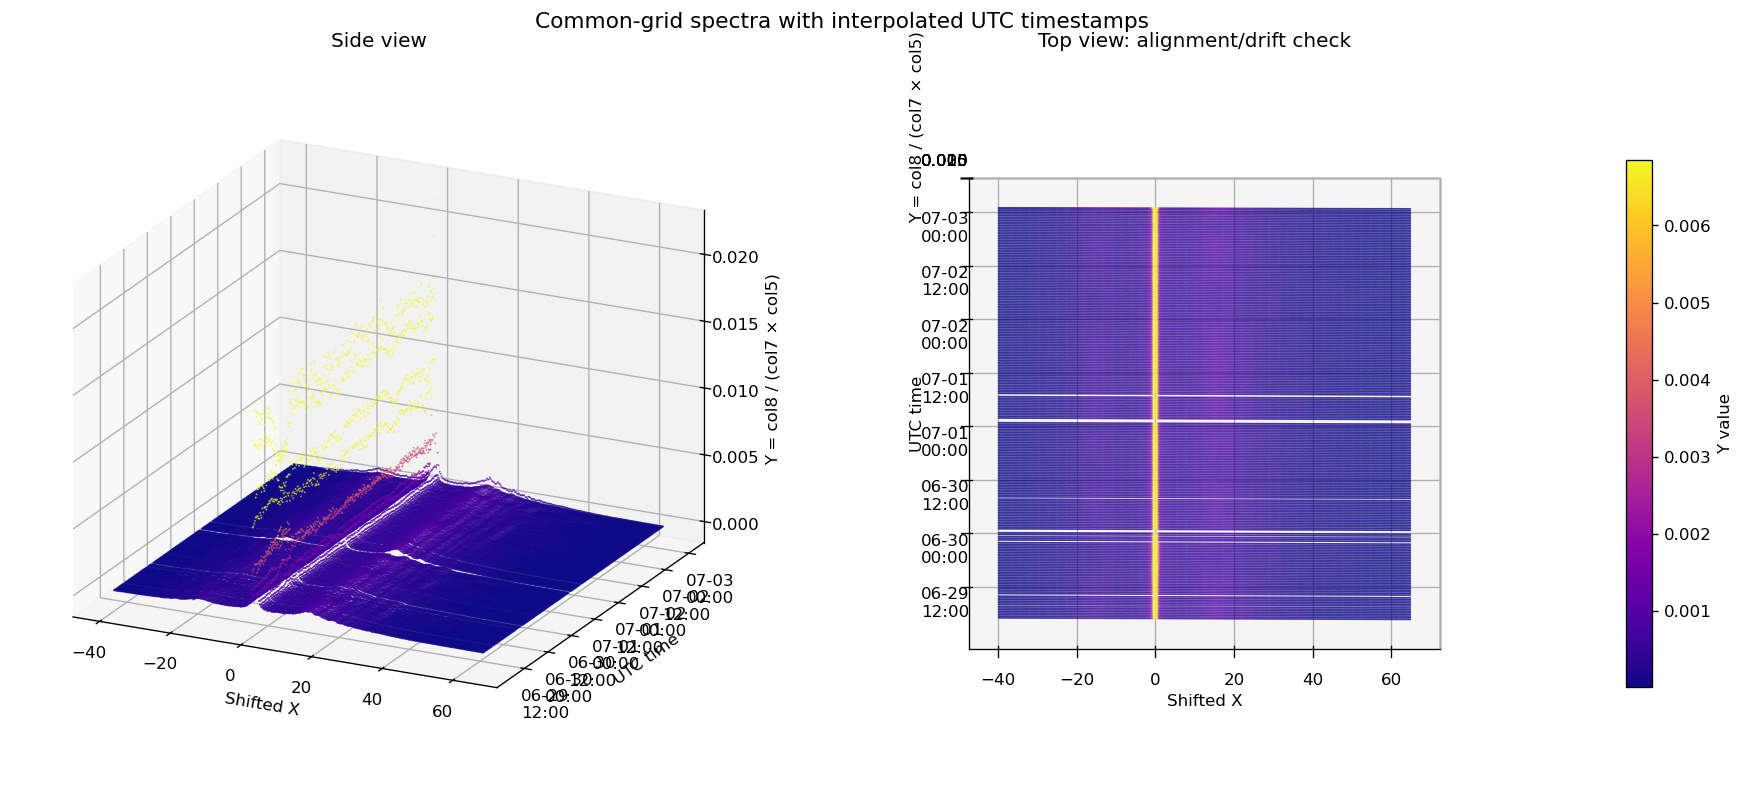

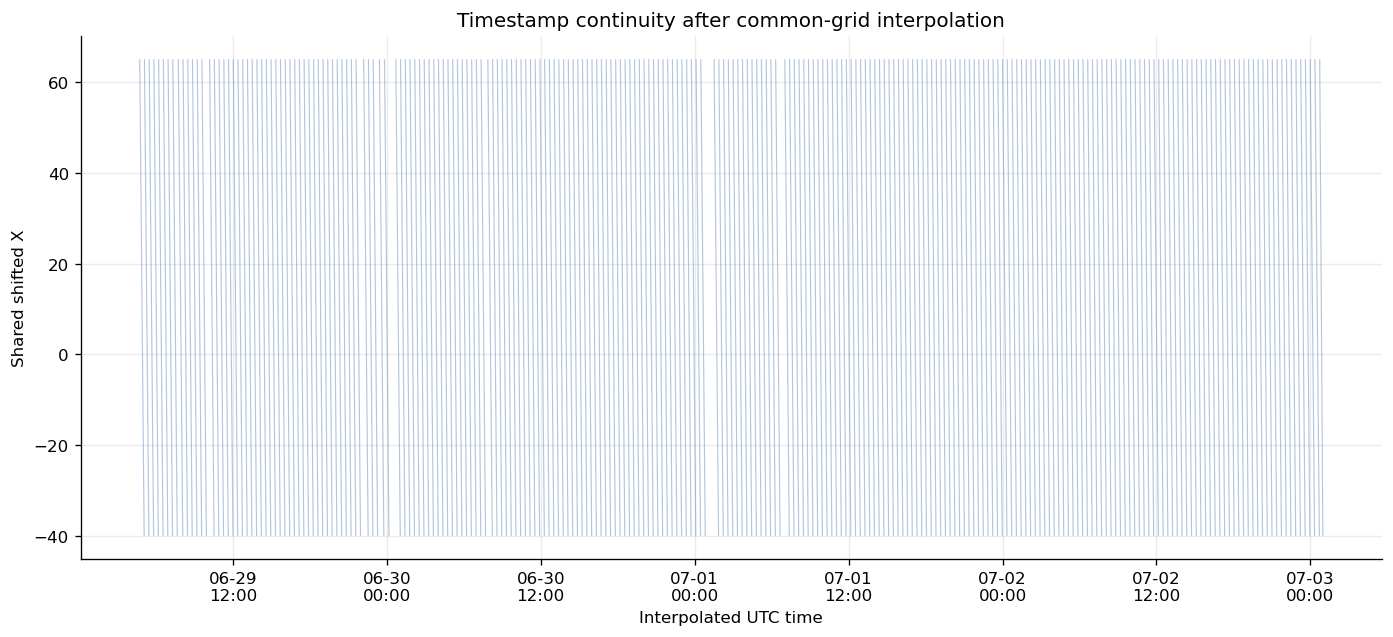

In [5]:
# Match the original CSV-reading stage: sort each per-scan dataframe by UTC time.
dfs_by_file = {}
for record in kept_records:
    frame = pd.DataFrame({
        "x": record["x_shifted"],
        "y": record["y"],
        "time_utc": pd.to_datetime(record["time_utc"], utc=True),
    })
    dfs_by_file[record["name"]] = frame.sort_values("time_utc", kind="mergesort").reset_index(drop=True)

first_x_by_file = {name: float(frame["x"].iloc[0]) for name, frame in dfs_by_file.items()}
last_x_by_file = {name: float(frame["x"].iloc[-1]) for name, frame in dfs_by_file.items()}
file_min_first_x = min(first_x_by_file, key=first_x_by_file.get)
file_max_last_x = max(last_x_by_file, key=last_x_by_file.get)
x_max_common = first_x_by_file[file_min_first_x]
x_min_common = last_x_by_file[file_max_last_x]
if not np.isfinite(x_min_common) or not np.isfinite(x_max_common) or x_min_common >= x_max_common:
    raise RuntimeError("Invalid common X range from 0th/last points")

n_common = max(len(frame) for frame in dfs_by_file.values())
x_common_grid = np.linspace(x_min_common, x_max_common, n_common)
dfs_interp_by_file = {}

for name, frame in dfs_by_file.items():
    x = frame["x"].to_numpy(dtype=float)
    y = frame["y"].to_numpy(dtype=float)
    time_nanoseconds = datetime_to_ns(frame["time_utc"])
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]
    time_sorted = time_nanoseconds[order]
    x_unique, first_index = np.unique(x_sorted, return_index=True)
    y_unique = y_sorted[first_index]
    time_unique = time_sorted[first_index].astype(float)

    if len(x_unique) < 2:
        y_interpolated = np.full_like(x_common_grid, float(np.nanmean(y_unique)))
        time_interpolated = np.full_like(x_common_grid, float(np.nanmean(time_unique)))
    else:
        y_interpolated = np.interp(x_common_grid, x_unique, y_unique)
        time_interpolated = np.interp(x_common_grid, x_unique, time_unique)

    dfs_interp_by_file[name] = pd.DataFrame({
        "x": x_common_grid,
        "y_interp": y_interpolated,
        "time_utc_interp": pd.to_datetime(
            np.rint(time_interpolated).astype(np.int64), utc=True, unit="ns"
        ),
    })

print(f"Common X grid: [{x_min_common:.6f}, {x_max_common:.6f}] with {n_common} points")
print(f"x_max boundary: {file_min_first_x} → {x_max_common:.6f}")
print(f"x_min boundary: {file_max_last_x} → {x_min_common:.6f}")

interpolated_records = [
    {"name": name, "x": frame["x"].to_numpy(), "y_interp": frame["y_interp"].to_numpy(),
     "time_utc_interp": list(frame["time_utc_interp"].dt.to_pydatetime())}
    for name, frame in sorted(dfs_interp_by_file.items())
]
waterfall_views(interpolated_records, "x", "y_interp", "time_utc_interp",
                "Common-grid spectra with interpolated UTC timestamps", point_size=1.15)

fig, ax = plt.subplots(figsize=(11.5, 5.2), constrained_layout=True)
for frame in dfs_interp_by_file.values():
    ax.plot(frame["time_utc_interp"], frame["x"], linewidth=0.7, alpha=0.42, color="#4C78A8")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
ax.set(xlabel="Interpolated UTC time", ylabel="Shared shifted X", title="Timestamp continuity after common-grid interpolation")
ax.grid(alpha=0.25)
plt.show()

## 5. Interpolate each spectrum at one representative time

Each common-grid scan is assigned its median interpolated timestamp. For every X value, the signal is then linearly interpolated as a function of time across all scans at that scan’s median time. This is the final operation in the original workflow; `np.interp` retains its original endpoint behaviour for targets outside the sampled time span.


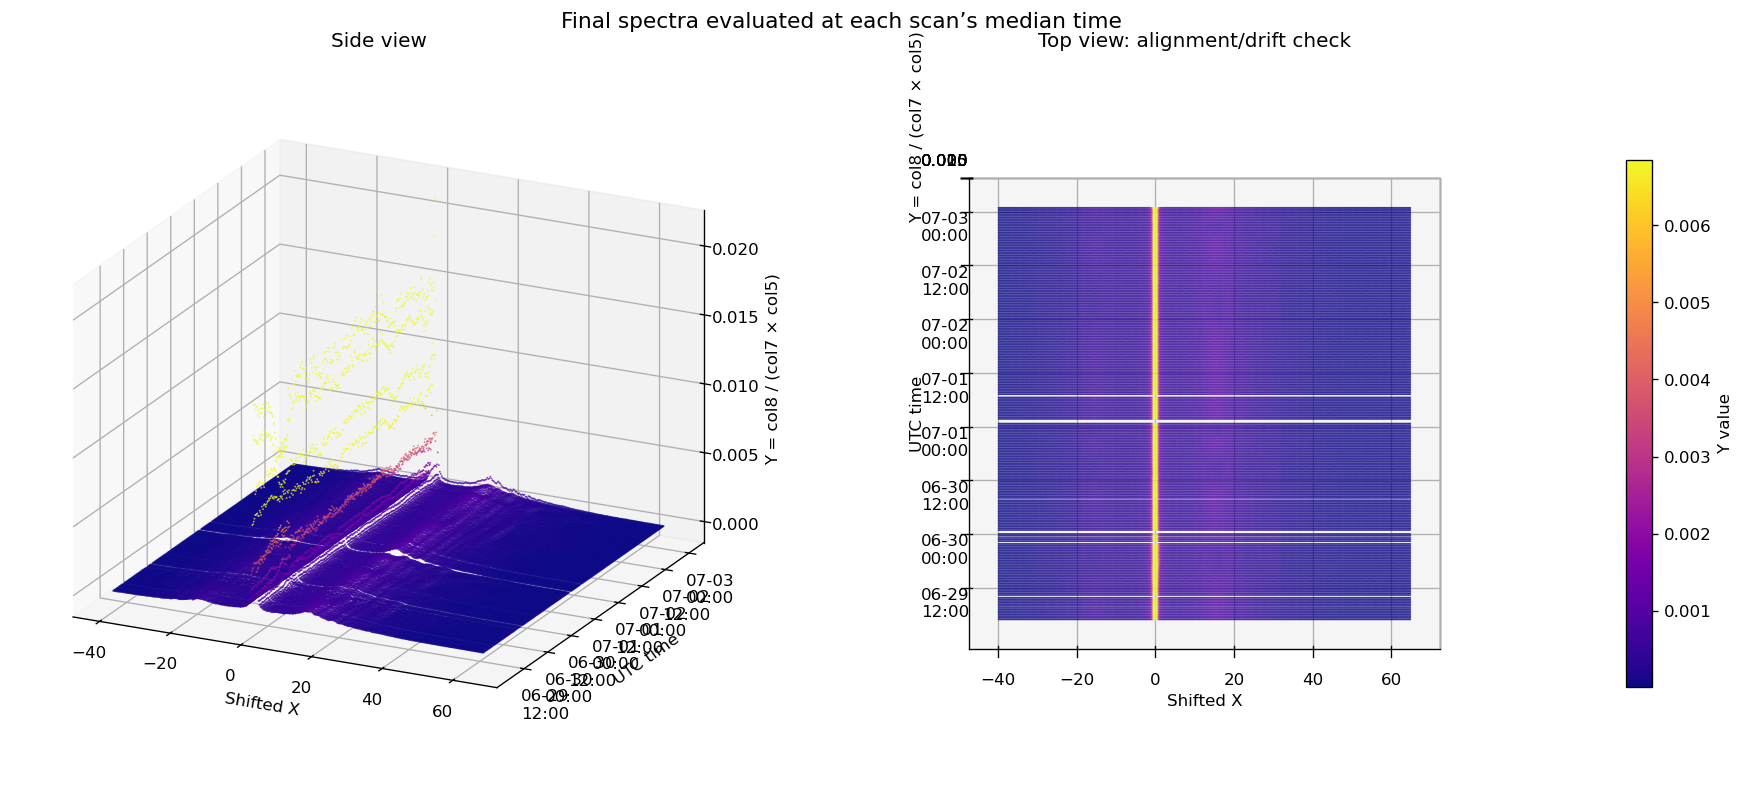

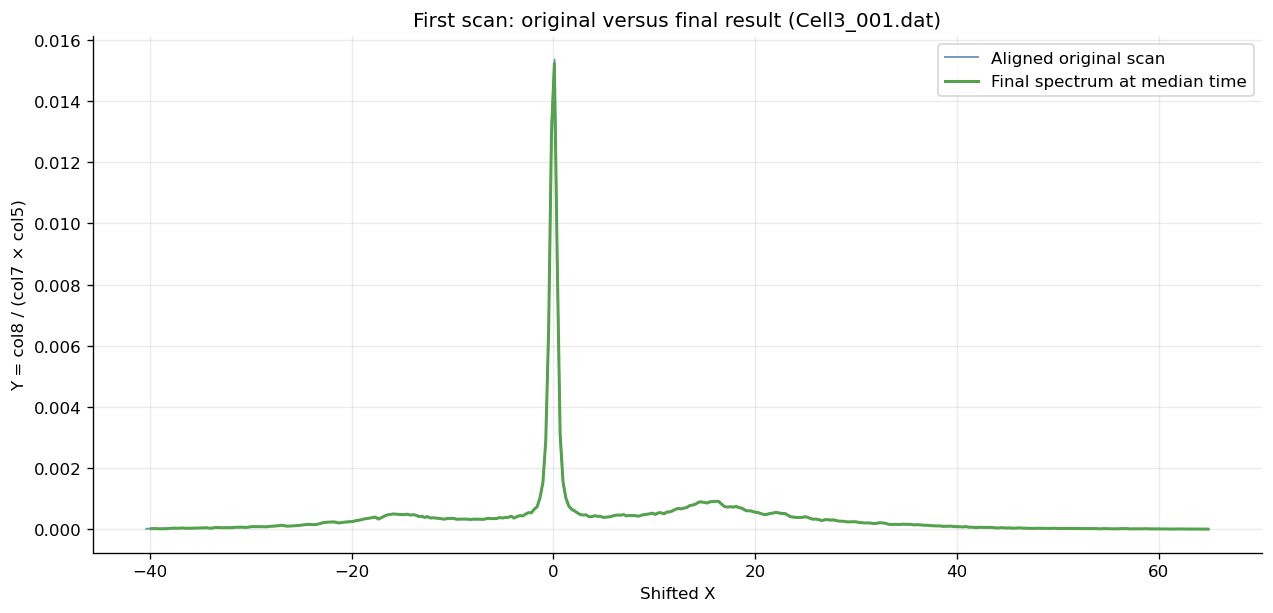

Final spectra: 244
Points per final spectrum: 368
First final spectrum timestamp: 2026-06-29T04:54:57.198173952+00:00


In [6]:
file_names = sorted(dfs_interp_by_file)
x_common = dfs_interp_by_file[file_names[0]]["x"].to_numpy(dtype=float)
n_files, n_x = len(file_names), len(x_common)
time_ns_matrix = np.empty((n_files, n_x), dtype=np.int64)
y_matrix = np.empty((n_files, n_x), dtype=float)

for row, name in enumerate(file_names):
    frame = dfs_interp_by_file[name]
    if len(frame) != n_x or not np.allclose(frame["x"].to_numpy(dtype=float), x_common):
        raise RuntimeError(f"Inconsistent common X grid in {name}")
    time_ns_matrix[row] = datetime_to_ns(frame["time_utc_interp"])
    y_matrix[row] = frame["y_interp"].to_numpy(dtype=float)

median_time_ns = np.median(time_ns_matrix, axis=1).astype(np.int64)
dfs_y_at_median_time_by_file = {}

for row, name in enumerate(file_names):
    target_time = median_time_ns[row]
    y_at_median_time = np.empty(n_x, dtype=float)
    for column in range(n_x):
        source_time = time_ns_matrix[:, column].astype(float)
        source_y = y_matrix[:, column]
        order = np.argsort(source_time)
        time_sorted, y_sorted = source_time[order], source_y[order]
        time_unique, first_index = np.unique(time_sorted, return_index=True)
        y_unique = y_sorted[first_index]
        y_at_median_time[column] = (
            float(np.nanmean(y_unique)) if len(time_unique) < 2
            else float(np.interp(float(target_time), time_unique, y_unique))
        )

    dfs_y_at_median_time_by_file[name] = pd.DataFrame({
        "x": x_common,
        "y_at_median_time": y_at_median_time,
        "median_time_utc": pd.to_datetime(
            np.full(n_x, target_time, dtype=np.int64), utc=True, unit="ns"
        ),
    })

final_records = [
    {"name": name, "x": frame["x"].to_numpy(), "y_final": frame["y_at_median_time"].to_numpy(),
     "median_time_utc": [frame["median_time_utc"].iloc[0]] * len(frame)}
    for name, frame in sorted(dfs_y_at_median_time_by_file.items())
]
waterfall_views(final_records, "x", "y_final", "median_time_utc",
                "Final spectra evaluated at each scan’s median time", point_size=1.2)

# Compare the first scan before and after the final time interpolation.
first_name = file_names[0]
first_original = dfs_by_file[first_name]
first_final = dfs_y_at_median_time_by_file[first_name]
fig, ax = plt.subplots(figsize=(10.5, 5.0), constrained_layout=True)
ax.plot(first_original["x"], first_original["y"], color="#4C78A8", alpha=0.78,
        linewidth=1.15, label="Aligned original scan")
ax.plot(first_final["x"], first_final["y_at_median_time"], color="#54A24B", linewidth=1.8,
        label="Final spectrum at median time")
ax.set(xlabel="Shifted X", ylabel="Y = col8 / (col7 × col5)",
       title=f"First scan: original versus final result ({first_name})")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

print(f"Final spectra: {len(dfs_y_at_median_time_by_file)}")
print(f"Points per final spectrum: {n_x}")
print(f"First final spectrum timestamp: {first_final['median_time_utc'].iloc[0].isoformat()}")

## 6. Reproducibility summary and optional export

The analysis objects below are the final result:

- `dfs_by_file`: aligned, timestamped scan data;
- `dfs_interp_by_file`: scan data on the common X grid, with interpolated timestamps;
- `dfs_y_at_median_time_by_file`: final spectra evaluated at each scan’s median time.

The original notebook saved intermediate files during analysis. This clean version avoids changing the legacy export folders by default. Set `WRITE_FINAL_CSV = True` only when an explicit CSV export is needed.


In [7]:
summary = pd.DataFrame({
    "metric": [
        "Input files found", "Valid scans loaded", "Incomplete scans rejected",
        "Scans retained", "Common-grid points", "Final spectra",
    ],
    "value": [len(dat_files), len(raw_records), len(bad_scan_records), len(kept_records), n_x,
              len(dfs_y_at_median_time_by_file)],
})
display(summary)

WRITE_FINAL_CSV = False
OUTPUT_DIR = Path("drift_analysis_clean_output")

if WRITE_FINAL_CSV:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, frame in dfs_y_at_median_time_by_file.items():
        output = frame[["x", "y_at_median_time", "median_time_utc"]].copy()
        output.to_csv(OUTPUT_DIR / f"{Path(name).stem}_final_median_time.csv", index=False)
    print(f"Wrote {len(dfs_y_at_median_time_by_file)} final CSV files to {OUTPUT_DIR.resolve()}")
else:
    print("No files written. Set WRITE_FINAL_CSV = True to export final spectra.")

,metric,value
0,Input files found,246
1,Valid scans loaded,246
2,Incomplete scans rejected,2
3,Scans retained,244
4,Common-grid points,368
5,Final spectra,244


No files written. Set WRITE_FINAL_CSV = True to export final spectra.
